In [124]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [125]:
from langgraph.graph import MessageGraph

class ChatState(MessageGraph):
    summary : str
    messages : Annotated[list, add_messages]

In [126]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")

db = client["chatbot_db"]
collection = db["chat_memory"]

In [127]:
# Save Chat

import uuid
from datetime import datetime

def save_message(thread_id: str, role: str, content: str):

    collection.update_one(
        {"thread_id": thread_id},
        {
            "$push": {
                "messages": {
                    "id": str(uuid.uuid4()),
                    "role": role,
                    "content": content,
                    "timestamp": datetime.utcnow()
                }
            }
        },
        upsert=True
    )

In [128]:
# load chat

def load_state(thread_id):

    chat = collection.find_one({"thread_id": thread_id})

    if not chat:
        return {
            "messages": [],
            "summary": ""
        }

    history = []

    for msg in chat.get("messages", []):

        if msg["role"] == "user":
            history.append(HumanMessage(content=msg["content"]))

        else:
            history.append(AIMessage(content=msg["content"]))

    return {
        "messages": history,
        "summary": chat.get("summary", "")
    }

In [129]:
llm = ChatOpenAI(model="gpt-5-nano")

In [130]:
thread_id = "user_123"

In [131]:
from langchain_core.messages import RemoveMessage

def summarization_msgs(state: ChatState):

    existing_summary = state["summary"]

    if existing_summary:
        prompt = (
            f"Existing summary :: \n{existing_summary} \n\n"
            "Extend the summary using the new conversation above. and this summary must be or less then of 9-10 lines"
        )
    else :
        prompt = (
                    "give the summary using the new conversation above. and this summary must be or less then of 9-10 lines"
                )
    msgs_for_summary = state["messages"] + [HumanMessage(content=prompt)]

    response = llm.invoke(msgs_for_summary)

    collection.update_one(
        {"thread_id": thread_id},
        {
            "$set": {
                "summary": response.content
            }
        },
        upsert=True
    )

    msgs = state["messages"]

    num_to_delete = 6

    # Update MongoDB
    chat = collection.find_one({"thread_id": thread_id})

    if chat:

        remaining_messages = chat["messages"][num_to_delete:]

        collection.update_one(
            {"thread_id": thread_id},
            {
                "$set": {
                    "messages": remaining_messages
                }
            }
        )

    # Update LangGraph state
    return {
        "summary" : response.content,
        "messages": [
            RemoveMessage(id=m.id)
            for m in msgs[:num_to_delete]
        ]
    }

In [132]:
def should_summarize(state : ChatState):
    return len(state["messages"]) > 6

In [133]:
from langchain_core.messages import SystemMessage, AIMessage

def llm_chat(state: ChatState):

    messages = []

    # Add summary if it exists
    if state.get("summary"):
        messages.append(
            SystemMessage(
                content=f"""
Conversation Summary:

{state['summary']}

Use this summary as context while answering.
"""
            )
        )

    # Add all previous chat messages
    messages.extend(state["messages"])

    # Call LLM
    result = llm.invoke(messages)

    # Return AI message
    return {
        "messages": [
            AIMessage(content=result.content)
        ]
    }

In [134]:
graph = StateGraph(ChatState)

graph.add_node("llm_chat",llm_chat)
graph.add_node("summarization",summarization_msgs)

graph.add_edge(START,"llm_chat")
graph.add_conditional_edges("llm_chat", should_summarize,{True : "summarization", False : END})
graph.add_edge("summarization", END)

workflow = graph.compile()

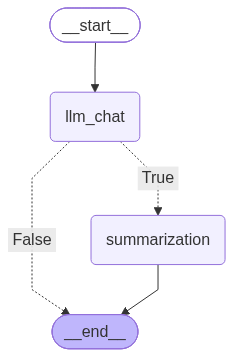

In [135]:
workflow

In [146]:
user_message = input("Enter the query here :: ")

In [147]:
state = load_state(thread_id)

state["messages"].append(
    HumanMessage(content=user_message)
)

final_result = workflow.invoke(state)

In [148]:
answer = final_result["messages"][-1].content

In [149]:
save_message(thread_id, "user", user_message)
save_message(thread_id, "assistant", answer)

if final_result.get("summary"):

    collection.update_one(
        {"thread_id": thread_id},
        {
            "$set": {
                "summary": final_result["summary"]
            }
        },
        upsert=True
    )

C:\Users\rudra\AppData\Local\Temp\ipykernel_10208\3647117187.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow()


In [150]:
for message in final_result["messages"]:
    print(message.content)

what is my name? give answer in just 1 line
Rudra
what is 2+3 give answer in just one word
five
